# 🫁 Chest X-Ray Lung Segmentation
**Features:** Z-score Normalization · Albumentations Augmentation · CNN / U-Net ResNet34 / U-Net ResNet50 / BGG (DeepLabV3+)
- ✅ Fix: Cell 10 ใช้ trained model จริง (save/load weights)
- ✅ เพิ่ม Loss curve graph
- ✅ เพิ่ม IoU / Dice curve graph

## 📦 1. Install Dependencies

In [1]:
!pip install opendatasets --upgrade -q
!pip install -q segmentation-models-pytorch timm albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:0000:01


## 📥 2. Download Dataset

In [2]:
# import opendatasets as od
# od.download('https://www.kaggle.com/datasets/iamtapendu/chest-x-ray-lungs-segmentation')

In [3]:
import os

base_dir = '/kaggle/input/datasets/iamtapendu/chest-x-ray-lungs-segmentation/Chest-X-Ray/Chest-X-Ray'
image_dir = os.path.join(base_dir, 'image')
mask_dir  = os.path.join(base_dir, 'mask')

print('โฟลเดอร์:',       os.listdir(base_dir))
print('จำนวน image:',    len(os.listdir(image_dir)))
print('จำนวน mask:',     len(os.listdir(mask_dir)))
print('ตัวอย่าง 5 ไฟล์:', sorted(os.listdir(image_dir))[:5])

โฟลเดอร์: ['mask', 'image']
จำนวน image: 704
จำนวน mask: 704
ตัวอย่าง 5 ไฟล์: ['1000.png', '1001.png', '1002.png', '1003.png', '1004.png']


## 🔧 3. Dataset — Normalization + Augmentation
- **Z-score per image**: `(pixel - mean) / std`
- **Augmentations**: HorizontalFlip · Rotate · ElasticTransform · BrightnessContrast · GaussNoise · CLAHE

In [4]:
import os
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import albumentations as A

TRAIN_TRANSFORM = A.Compose([
    A.Resize(128, 128),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.ElasticTransform(alpha=120, sigma=120*0.05, alpha_affine=120*0.03, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.3),
])

VAL_TRANSFORM = A.Compose([
    A.Resize(128, 128),
])

def normalize_zscore(image):
    mean = image.mean()
    std  = image.std() + 1e-6
    return (image - mean) / std

class LungDataset(Dataset):
    def __init__(self, image_dir, mask_dir, file_list, transform=None):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.files     = file_list
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_name  = self.files[idx]
        image = cv2.imread(os.path.join(self.image_dir, img_name), cv2.IMREAD_GRAYSCALE)
        mask  = cv2.imread(os.path.join(self.mask_dir,  img_name), cv2.IMREAD_GRAYSCALE)

        if image is None or mask is None:
            raise ValueError(f'Cannot read {img_name}')

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask']

        image = normalize_zscore(image.astype(np.float32))
        mask  = (mask > 127).astype(np.float32)

        image = np.expand_dims(image, axis=0)
        mask  = np.expand_dims(mask,  axis=0)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)


all_files = [f for f in os.listdir(image_dir) if f.endswith('.png')]
train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42)

train_dataset = LungDataset(image_dir, mask_dir, train_files, transform=TRAIN_TRANSFORM)
val_dataset   = LungDataset(image_dir, mask_dir, val_files,   transform=VAL_TRANSFORM)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_dataset)}  |  Val: {len(val_dataset)}')

Train: 563  |  Val: 141


/tmp/ipykernel_55/1267092341.py:13: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=120, sigma=120*0.05, alpha_affine=120*0.03, p=0.3),
/tmp/ipykernel_55/1267092341.py:15: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),


## 🧠 4. Models
| Model | Architecture |
|---|---|
| CNN | Simple ConvNet (baseline) |
| U-Net | ResNet34 encoder |
| ResNet | ResNet50 encoder |
| **BGG** | **DeepLabV3+ ResNet50 + ASPP** |

In [5]:
import segmentation_models_pytorch as smp
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ConvTranspose2d(32,  1, 2, stride=2)
        )
    def forward(self, x):
        return self.model(x)

def get_unet():
    return smp.Unet(encoder_name='resnet34', encoder_weights='imagenet', in_channels=1, classes=1)

def get_resnet():
    return smp.Unet(encoder_name='resnet50', encoder_weights='imagenet', in_channels=1, classes=1)

def get_bgg():
    return smp.DeepLabV3Plus(
        encoder_name='resnet50',
        encoder_weights='imagenet',
        in_channels=1,
        classes=1,
        encoder_output_stride=16,
        decoder_atrous_rates=(6, 12, 18)
    )

def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum()
    return 1 - (2. * intersection) / (pred.sum() + target.sum() + 1e-6)

criterion = nn.BCEWithLogitsLoss()
print('Models defined ✅')

Models defined ✅


## 📊 5. Metrics

In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def compute_metrics(preds, labels):
    preds_bin = (torch.sigmoid(preds) > 0.5).cpu().numpy().flatten().astype(int)
    labels_np = labels.cpu().numpy().flatten().astype(int)

    acc       = accuracy_score(labels_np, preds_bin)
    precision = precision_score(labels_np, preds_bin, zero_division=0)
    recall    = recall_score(labels_np, preds_bin, zero_division=0)
    f1        = f1_score(labels_np, preds_bin, zero_division=0)

    intersection = np.logical_and(preds_bin, labels_np).sum()
    union        = np.logical_or(preds_bin, labels_np).sum()
    iou          = intersection / (union + 1e-6)
    dice         = (2 * intersection) / (preds_bin.sum() + labels_np.sum() + 1e-6)

    return acc, precision, recall, f1, iou, dice

print('Metrics defined ✅')

Metrics defined ✅


## 🏋️ 6. Training Loop
- บันทึก **train loss** ทุก epoch
- บันทึก **val IoU / Dice** ทุก epoch
- **Save model weights** หลัง train เสร็จ (ใช้ใน Cell 10)

In [7]:
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

os.makedirs('saved_models', exist_ok=True)

def train_model(model, name, save_key, epochs=10, lr=1e-4):
    model     = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_dice  = 0.0
    best_epoch = 0

    # ── history ──
    hist_train_loss = []
    hist_iou        = []
    hist_dice       = []
    hist_metrics    = []

    print(f'\n{"="*55}')
    print(f'  Training: {name}')
    print(f'{"="*55}')

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y) + dice_loss(pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        scheduler.step()
        avg_loss = train_loss / len(train_loader)
        hist_train_loss.append(avg_loss)

        model.eval()
        all_metrics = []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x)
                all_metrics.append(compute_metrics(pred, y))

        avg = np.mean(all_metrics, axis=0)
        hist_iou.append(avg[4])
        hist_dice.append(avg[5])
        hist_metrics.append(avg)

        if avg[5] > best_dice:
            best_dice  = avg[5]
            best_epoch = epoch + 1
            # ── Save best weights ──
            torch.save(model.state_dict(), f'saved_models/{save_key}.pth')

        print(f'Epoch {epoch+1:2d}/{epochs}  '
              f'Loss: {avg_loss:.4f}  '
              f'Acc: {avg[0]:.4f}  Prec: {avg[1]:.4f}  Rec: {avg[2]:.4f}  '
              f'F1: {avg[3]:.4f}  IoU: {avg[4]:.4f}  Dice: {avg[5]:.4f}')

    print(f'\n✅ Best Dice: {best_dice:.4f} @ Epoch {best_epoch}  (saved → saved_models/{save_key}.pth)')

    return avg, {
        'train_loss': hist_train_loss,
        'iou':  hist_iou,
        'dice': hist_dice,
        'metrics': hist_metrics
    }

Device: cuda


In [8]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


## 🚀 7. Run All Models

In [9]:
EPOCHS = 16
results   = {}
histories = {}

results['CNN'],     histories['CNN']     = train_model(SimpleCNN(),  'Simple CNN',              'cnn',    epochs=EPOCHS)
results['U-Net'],   histories['U-Net']   = train_model(get_unet(),   'U-Net ResNet34',          'unet',   epochs=EPOCHS)
results['ResNet'],  histories['ResNet']  = train_model(get_resnet(), 'U-Net ResNet50',          'resnet', epochs=EPOCHS)
results['BGG'],     histories['BGG']     = train_model(get_bgg(),    'BGG (DeepLabV3+ ResNet50)','bgg',   epochs=EPOCHS)


  Training: Simple CNN
Epoch  1/16  Loss: 1.3183  Acc: 0.8129  Prec: 0.7109  Rec: 0.4800  F1: 0.5654  IoU: 0.3972  Dice: 0.5654
Epoch  2/16  Loss: 1.0021  Acc: 0.8413  Prec: 0.7767  Rec: 0.5437  F1: 0.6334  IoU: 0.4680  Dice: 0.6334
Epoch  3/16  Loss: 0.8490  Acc: 0.8527  Prec: 0.7103  Rec: 0.7326  F1: 0.7170  IoU: 0.5622  Dice: 0.7170
Epoch  4/16  Loss: 0.7528  Acc: 0.8545  Prec: 0.6931  Rec: 0.7902  F1: 0.7350  IoU: 0.5843  Dice: 0.7350
Epoch  5/16  Loss: 0.7057  Acc: 0.8638  Prec: 0.7264  Rec: 0.7634  F1: 0.7404  IoU: 0.5912  Dice: 0.7404
Epoch  6/16  Loss: 0.6786  Acc: 0.8698  Prec: 0.7220  Rec: 0.8098  F1: 0.7603  IoU: 0.6167  Dice: 0.7603
Epoch  7/16  Loss: 0.6524  Acc: 0.8772  Prec: 0.7439  Rec: 0.8023  F1: 0.7690  IoU: 0.6279  Dice: 0.7690
Epoch  8/16  Loss: 0.6423  Acc: 0.8803  Prec: 0.7430  Rec: 0.8213  F1: 0.7775  IoU: 0.6394  Dice: 0.7775
Epoch  9/16  Loss: 0.6287  Acc: 0.8843  Prec: 0.7518  Rec: 0.8245  F1: 0.7838  IoU: 0.6479  Dice: 0.7838
Epoch 10/16  Loss: 0.6077  Acc:

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]


  Training: U-Net ResNet34
Epoch  1/16  Loss: 0.7015  Acc: 0.9592  Prec: 0.8942  Rec: 0.9522  F1: 0.9220  IoU: 0.8556  Dice: 0.9220
Epoch  2/16  Loss: 0.3593  Acc: 0.9724  Prec: 0.9527  Rec: 0.9391  F1: 0.9455  IoU: 0.8970  Dice: 0.9455
Epoch  3/16  Loss: 0.2619  Acc: 0.9730  Prec: 0.9370  Rec: 0.9589  F1: 0.9475  IoU: 0.9006  Dice: 0.9475
Epoch  4/16  Loss: 0.2172  Acc: 0.9748  Prec: 0.9432  Rec: 0.9592  F1: 0.9508  IoU: 0.9067  Dice: 0.9508
Epoch  5/16  Loss: 0.1944  Acc: 0.9768  Prec: 0.9567  Rec: 0.9522  F1: 0.9542  IoU: 0.9128  Dice: 0.9542
Epoch  6/16  Loss: 0.1745  Acc: 0.9774  Prec: 0.9593  Rec: 0.9520  F1: 0.9554  IoU: 0.9150  Dice: 0.9554
Epoch  7/16  Loss: 0.1658  Acc: 0.9782  Prec: 0.9613  Rec: 0.9535  F1: 0.9571  IoU: 0.9181  Dice: 0.9571
Epoch  8/16  Loss: 0.1559  Acc: 0.9776  Prec: 0.9543  Rec: 0.9582  F1: 0.9560  IoU: 0.9161  Dice: 0.9560
Epoch  9/16  Loss: 0.1538  Acc: 0.9784  Prec: 0.9598  Rec: 0.9557  F1: 0.9574  IoU: 0.9188  Dice: 0.9574
Epoch 10/16  Loss: 0.1467  

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]


  Training: U-Net ResNet50
Epoch  1/16  Loss: 0.7296  Acc: 0.9628  Prec: 0.8992  Rec: 0.9613  F1: 0.9288  IoU: 0.8675  Dice: 0.9288
Epoch  2/16  Loss: 0.3906  Acc: 0.9697  Prec: 0.9221  Rec: 0.9619  F1: 0.9412  IoU: 0.8894  Dice: 0.9412
Epoch  3/16  Loss: 0.2779  Acc: 0.9753  Prec: 0.9557  Rec: 0.9473  F1: 0.9512  IoU: 0.9075  Dice: 0.9512
Epoch  4/16  Loss: 0.2252  Acc: 0.9768  Prec: 0.9645  Rec: 0.9439  F1: 0.9538  IoU: 0.9122  Dice: 0.9538
Epoch  5/16  Loss: 0.1923  Acc: 0.9770  Prec: 0.9561  Rec: 0.9538  F1: 0.9547  IoU: 0.9137  Dice: 0.9547
Epoch  6/16  Loss: 0.1762  Acc: 0.9762  Prec: 0.9459  Rec: 0.9615  F1: 0.9534  IoU: 0.9114  Dice: 0.9534
Epoch  7/16  Loss: 0.1651  Acc: 0.9774  Prec: 0.9546  Rec: 0.9573  F1: 0.9557  IoU: 0.9156  Dice: 0.9557
Epoch  8/16  Loss: 0.1570  Acc: 0.9785  Prec: 0.9629  Rec: 0.9527  F1: 0.9575  IoU: 0.9190  Dice: 0.9575
Epoch  9/16  Loss: 0.1510  Acc: 0.9784  Prec: 0.9595  Rec: 0.9556  F1: 0.9573  IoU: 0.9186  Dice: 0.9573
Epoch 10/16  Loss: 0.1447  

## 📈 8. Summary

In [14]:
for k, v in results.items():
    print(f"Model: {k}")
    print(f"  type(v): {type(v)}")
    print(f"  v: {v}")
    print()

Model: CNN
  type(v): <class 'numpy.ndarray'>
  v: [0.89211655 0.76969592 0.83051405 0.79649286 0.66504867 0.79649286]

Model: U-Net
  type(v): <class 'numpy.ndarray'>
  v: [0.97890642 0.96136742 0.95620334 0.95854172 0.92083171 0.95854172]

Model: ResNet
  type(v): <class 'numpy.ndarray'>
  v: [0.97932985 0.96275124 0.95636646 0.95932296 0.92223594 0.95932296]

Model: BGG
  type(v): <class 'numpy.ndarray'>
  v: [0.97793579 0.96829507 0.94485372 0.95616544 0.91638692 0.95616544]



In [15]:
import pandas as pd

rows = []
for k, v in results.items():
    rows.append({
        'Model':     k,
        'Accuracy':  round(float(v[0]), 4),
        'Precision': round(float(v[1]), 4),
        'Recall':    round(float(v[2]), 4),
        'F1':        round(float(v[3]), 4),
        'IoU':       round(float(v[4]), 4),
        'Dice':      round(float(v[5]), 4),
    })

df = pd.DataFrame(rows).set_index('Model')
print('\n' + '='*60)
print(' FINAL RESULTS')
print('='*60)
print(df.to_string())
print(f'\n🏆 Best Model by Dice: {df["Dice"].idxmax()}')


 FINAL RESULTS
        Accuracy  Precision  Recall      F1     IoU    Dice
Model                                                      
CNN       0.8921     0.7697  0.8305  0.7965  0.6650  0.7965
U-Net     0.9789     0.9614  0.9562  0.9585  0.9208  0.9585
ResNet    0.9793     0.9628  0.9564  0.9593  0.9222  0.9593
BGG       0.9779     0.9683  0.9449  0.9562  0.9164  0.9562

🏆 Best Model by Dice: ResNet


## 📉 9. Training Curves — Loss · IoU · Dice

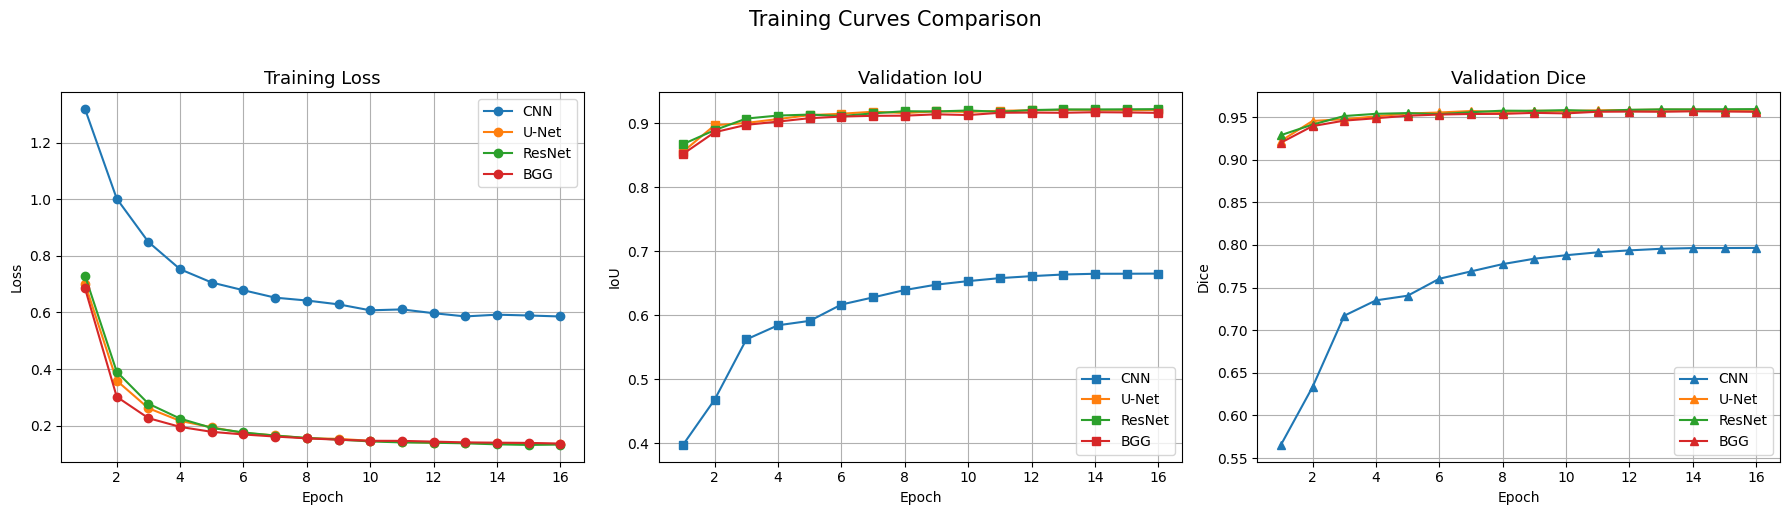

Saved: training_curves.png


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, hist in histories.items():
    epochs_range = range(1, len(hist['train_loss']) + 1)
    axes[0].plot(epochs_range, hist['train_loss'], marker='o', label=name)
    axes[1].plot(epochs_range, hist['iou'],        marker='s', label=name)
    axes[2].plot(epochs_range, hist['dice'],       marker='^', label=name)

axes[0].set_title('Training Loss',    fontsize=13); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss');  axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Validation IoU',   fontsize=13); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('IoU');   axes[1].legend(); axes[1].grid(True)
axes[2].set_title('Validation Dice',  fontsize=13); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Dice');  axes[2].legend(); axes[2].grid(True)

plt.suptitle('Training Curves Comparison', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

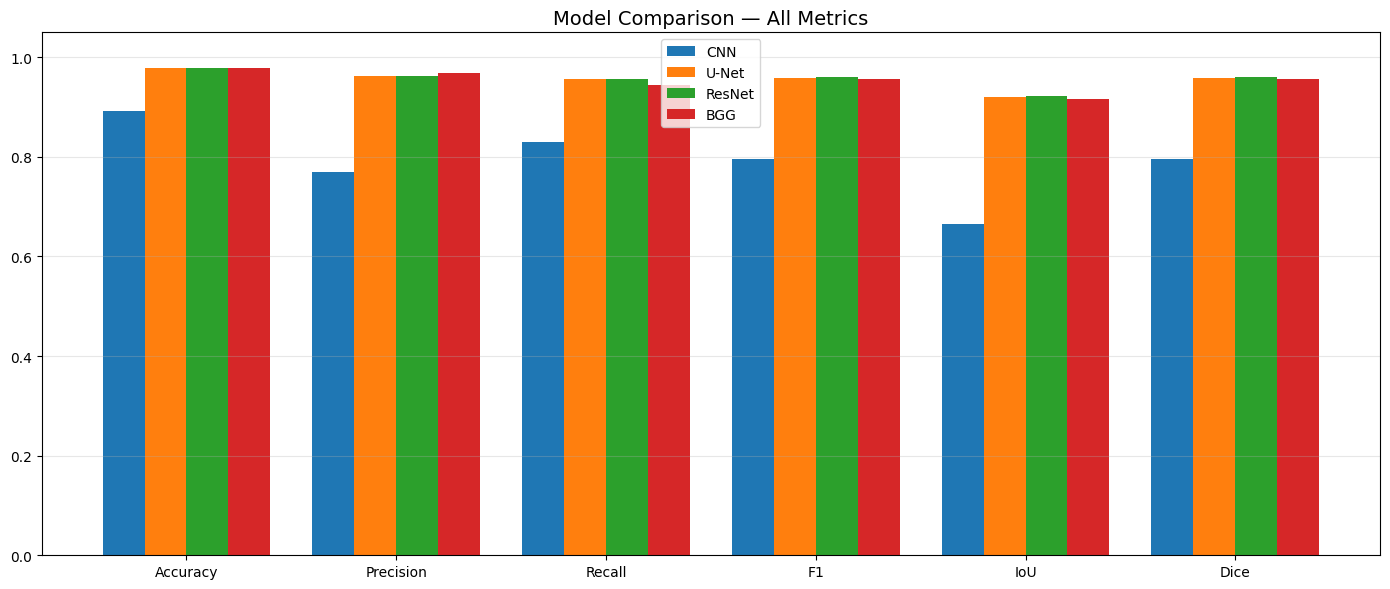

In [17]:
import matplotlib.pyplot as plt
import numpy as np

models = list(results.keys())
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'IoU', 'Dice']
values = np.array([results[m] for m in models])

x = np.arange(len(metrics_names))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
for i, model in enumerate(models):
    ax.bar(x + i * width, values[i], width, label=model)

ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison — All Metrics', fontsize=14)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## 🖼️ 10. Visualize Predictions
> **Fix:** โหลด trained weights จาก `saved_models/*.pth` ก่อน inference

✅ Loaded: saved_models/cnn.pth
✅ Loaded: saved_models/unet.pth
✅ Loaded: saved_models/resnet.pth
✅ Loaded: saved_models/bgg.pth


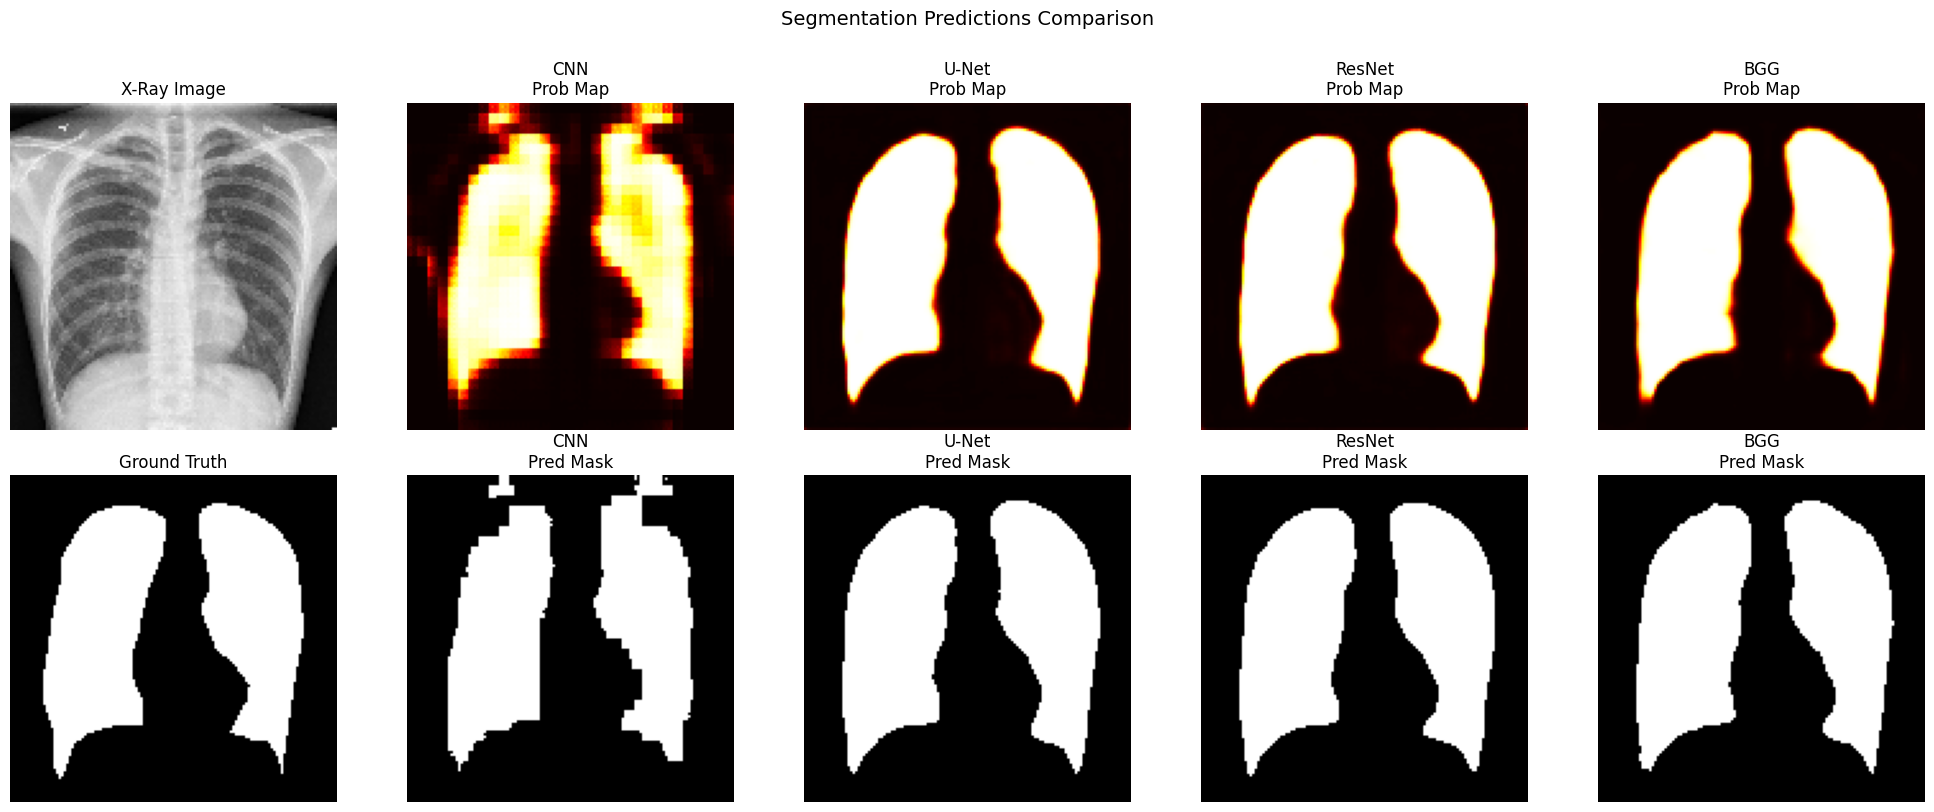

Saved: predictions_comparison.png


In [18]:
import matplotlib.pyplot as plt

# ── โหลด val sample ──
sample_img, sample_mask = val_dataset[0]
sample_img_batch = sample_img.unsqueeze(0).to(device)

# ── map ชื่อ → (model_fn, save_key) ──
model_registry = {
    'CNN':    (SimpleCNN,  'cnn'),
    'U-Net':  (get_unet,   'unet'),
    'ResNet': (get_resnet, 'resnet'),
    'BGG':    (get_bgg,    'bgg'),
}

n_models = len(results)
fig, axes = plt.subplots(2, n_models + 1, figsize=(4 * (n_models + 1), 8))

# ── Col 0: Original image + Ground Truth ──
axes[0][0].imshow(sample_img.squeeze().cpu().numpy(), cmap='gray')
axes[0][0].set_title('X-Ray Image'); axes[0][0].axis('off')
axes[1][0].imshow(sample_mask.squeeze().cpu().numpy(), cmap='gray')
axes[1][0].set_title('Ground Truth'); axes[1][0].axis('off')

# ── Col 1+: Prediction จากแต่ละ trained model ──
for col_i, (mname, _) in enumerate(results.items(), start=1):
    model_fn, save_key = model_registry[mname]
    weight_path = f'saved_models/{save_key}.pth'

    m = model_fn().to(device)

    if os.path.exists(weight_path):
        m.load_state_dict(torch.load(weight_path, map_location=device))
        print(f'✅ Loaded: {weight_path}')
    else:
        print(f'⚠️  Weight not found: {weight_path} — using random weights')

    m.eval()
    with torch.no_grad():
        pred = torch.sigmoid(m(sample_img_batch)).squeeze().cpu().numpy()
    pred_bin = (pred > 0.5).astype(np.float32)

    axes[0][col_i].imshow(pred,     cmap='hot');  axes[0][col_i].set_title(f'{mname}\nProb Map');  axes[0][col_i].axis('off')
    axes[1][col_i].imshow(pred_bin, cmap='gray'); axes[1][col_i].set_title(f'{mname}\nPred Mask'); axes[1][col_i].axis('off')

plt.suptitle('Segmentation Predictions Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('predictions_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: predictions_comparison.png')

✅ Loaded: saved_models/cnn.pth
✅ Loaded: saved_models/unet.pth
✅ Loaded: saved_models/resnet.pth
✅ Loaded: saved_models/bgg.pth


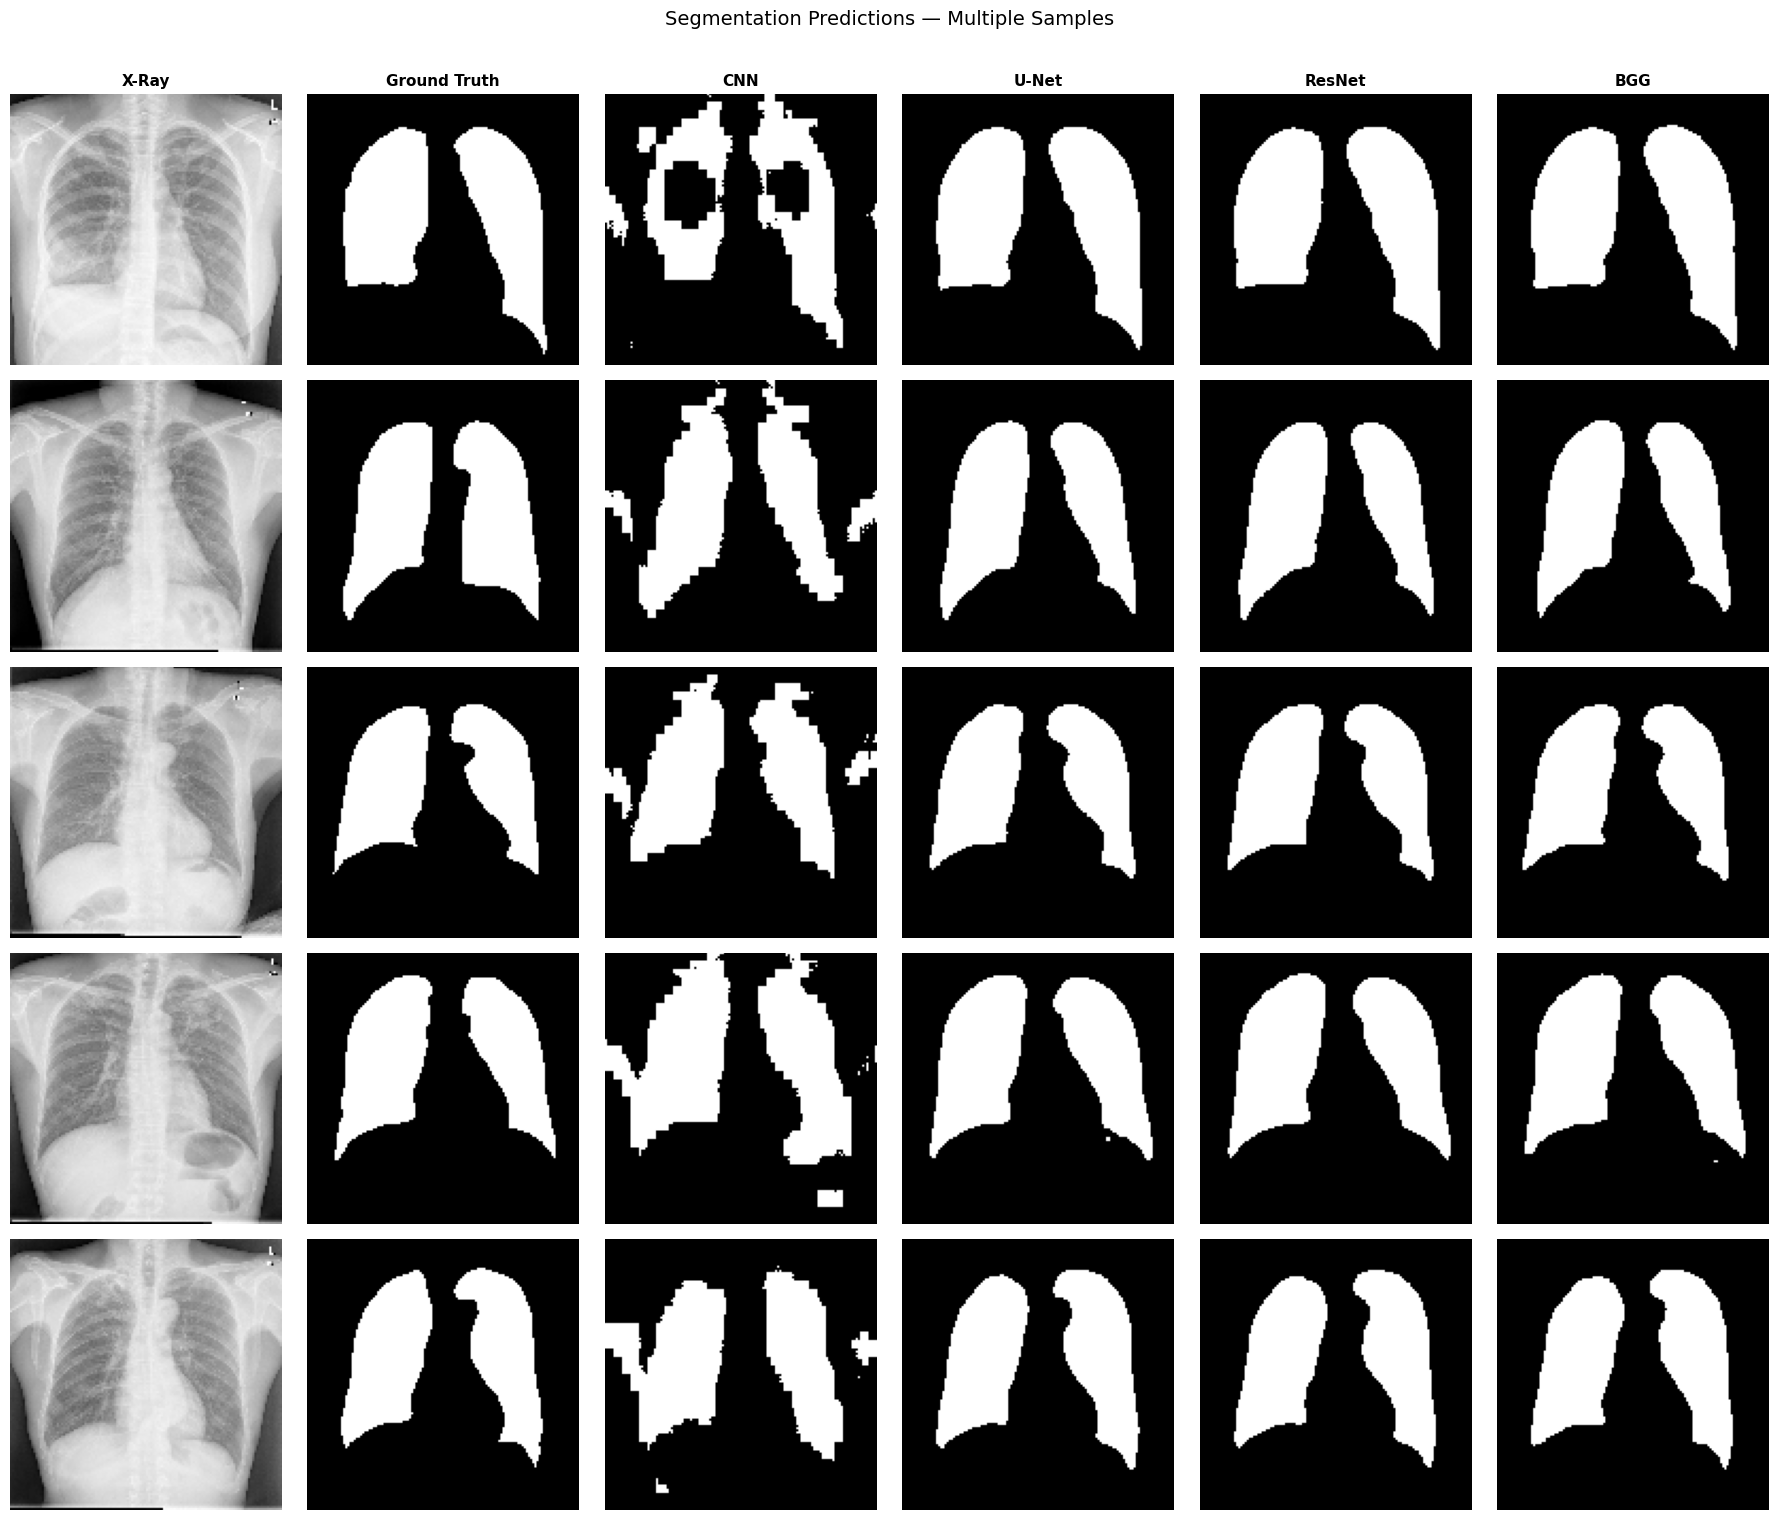

แสดง 5 รูป เสร็จแล้ว ✅


In [21]:
import matplotlib.pyplot as plt
import random

# ── เลือกจำนวนรูปที่อยากแสดง ──
NUM_SAMPLES = 5  # เปลี่ยนตรงนี้ได้เลย

# สุ่ม index จาก val_dataset
sample_indices = random.sample(range(len(val_dataset)), NUM_SAMPLES)

model_registry = {
    'CNN':    (SimpleCNN,  'cnn'),
    'U-Net':  (get_unet,   'unet'),
    'ResNet': (get_resnet, 'resnet'),
    'BGG':    (get_bgg,    'bgg'),
}

# โหลด trained models ครั้งเดียว
trained_models = {}
for mname, (model_fn, save_key) in model_registry.items():
    if mname not in results:
        continue
    m = model_fn().to(device)
    weight_path = f'saved_models/{save_key}.pth'
    if os.path.exists(weight_path):
        m.load_state_dict(torch.load(weight_path, map_location=device))
        print(f'✅ Loaded: {weight_path}')
    else:
        print(f'⚠️  ไม่พบ weight: {weight_path} → ใช้ random weights')
    m.eval()
    trained_models[mname] = m

n_models = len(trained_models)
col_labels = ['X-Ray', 'Ground Truth'] + list(trained_models.keys())

fig, axes = plt.subplots(NUM_SAMPLES, n_models + 2,
                         figsize=(3 * (n_models + 2), 3 * NUM_SAMPLES))

for row_i, idx in enumerate(sample_indices):
    sample_img, sample_mask = val_dataset[idx]
    sample_img_batch = sample_img.unsqueeze(0).to(device)

    # Col 0: X-Ray
    axes[row_i][0].imshow(sample_img.squeeze().cpu().numpy(), cmap='gray')
    axes[row_i][0].axis('off')
    if row_i == 0:
        axes[row_i][0].set_title('X-Ray', fontsize=11, fontweight='bold')

    # Col 1: Ground Truth
    axes[row_i][1].imshow(sample_mask.squeeze().cpu().numpy(), cmap='gray')
    axes[row_i][1].axis('off')
    if row_i == 0:
        axes[row_i][1].set_title('Ground Truth', fontsize=11, fontweight='bold')

    # Col 2+: Prediction จากแต่ละ model
    for col_i, (mname, m) in enumerate(trained_models.items(), start=2):
        with torch.no_grad():
            pred = torch.sigmoid(m(sample_img_batch)).squeeze().cpu().numpy()
        pred_bin = (pred > 0.5).astype(np.float32)

        axes[row_i][col_i].imshow(pred_bin, cmap='gray')
        axes[row_i][col_i].axis('off')
        if row_i == 0:
            axes[row_i][col_i].set_title(mname, fontsize=11, fontweight='bold')

    # Label แถวซ้ายมือ
    axes[row_i][0].set_ylabel(f'Sample {row_i+1}', fontsize=10, rotation=90, labelpad=10)

plt.suptitle('Segmentation Predictions — Multiple Samples', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('predictions_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'แสดง {NUM_SAMPLES} รูป เสร็จแล้ว ✅')

# ML

In [37]:
# ── Cell 11: โหลด MetaData และสร้าง label_map ──
import pandas as pd

meta_path = '/kaggle/input/datasets/iamtapendu/chest-x-ray-lungs-segmentation/MetaData.csv'
meta = pd.read_csv(meta_path)

label_map = {}
for _, row in meta.iterrows():
    fname = str(int(row['id'])) + '.png'   # 1000 → 1000.png
    label_map[fname] = int(row['ptb'])     # 0=normal, 1=TB

print(f'Total labels: {len(label_map)}')
print(meta[['id','gender','age','ptb']].head())

Total labels: 704
     id gender age  ptb
0  1000   male  31    0
1  1001   male  64    0
2  1002   male  35    0
3  1003   male  32    1
4  1004   male   2    1


In [38]:
# # ── Cell 12: Feature extraction จาก mask ──
# import cv2
# import numpy as np

# def extract_mask_features(binary_mask):
#     """สกัด 5 features จาก lung mask"""
#     mask = binary_mask.astype(np.uint8)
#     area = int(np.sum(mask))

#     contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#     if len(contours) == 0:
#         return None

#     cnt        = max(contours, key=cv2.contourArea)
#     perimeter  = cv2.arcLength(cnt, True)
#     hull       = cv2.convexHull(cnt)
#     hull_area  = cv2.contourArea(hull)

#     compactness = (perimeter ** 2) / (4 * np.pi * area) if area > 0 else 0
#     solidity    = area / hull_area if hull_area > 0 else 0

#     h, w  = mask.shape
#     left  = int(np.sum(mask[:, :w//2]))
#     right = int(np.sum(mask[:, w//2:]))
#     asymmetry = abs(left - right) / (left + right + 1e-6)

#     return [area, perimeter, compactness, solidity, asymmetry]

# print('Feature names: area, perimeter, compactness, solidity, asymmetry')



def extract_mask_features_v2(binary_mask, original_image=None):
    mask = binary_mask.astype(np.uint8)
    h, w = mask.shape
    mid  = w // 2

    # ── แยกปอดซ้าย-ขวา ──
    left_mask  = mask[:, :mid]
    right_mask = mask[:, mid:]

    left_area  = int(np.sum(left_mask))
    right_area = int(np.sum(right_mask))
    total_area = left_area + right_area

    if total_area == 0:
        return None

    # ── Shape features ──
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return None

    cnt         = max(contours, key=cv2.contourArea)
    perimeter   = cv2.arcLength(cnt, True)
    hull        = cv2.convexHull(cnt)
    hull_area   = cv2.contourArea(hull)

    compactness = (perimeter ** 2) / (4 * np.pi * total_area) if total_area > 0 else 0
    solidity    = total_area / hull_area if hull_area > 0 else 0
    asymmetry   = abs(left_area - right_area) / (total_area + 1e-6)

    # ── Bounding box ratio ──
    x, y, bw, bh = cv2.boundingRect(cnt)
    aspect_ratio  = bw / (bh + 1e-6)
    extent        = total_area / (bw * bh + 1e-6)  # สัดส่วนพื้นที่ใน bounding box

    # ── Texture features จากภาพจริงภายในปอด ──
    if original_image is not None:
        lung_pixels = original_image[mask == 1]
        if len(lung_pixels) > 0:
            mean_intensity = float(np.mean(lung_pixels))
            std_intensity  = float(np.std(lung_pixels))
            # histogram-based features
            hist, _ = np.histogram(lung_pixels, bins=8, range=(0, 256))
            hist = hist / (hist.sum() + 1e-6)
        else:
            mean_intensity = std_intensity = 0
            hist = np.zeros(8)
    else:
        mean_intensity = std_intensity = 0
        hist = np.zeros(8)

    features = [
        total_area, left_area, right_area,
        perimeter, compactness, solidity, asymmetry,
        aspect_ratio, extent,
        mean_intensity, std_intensity,
    ] + hist.tolist()   # 8 histogram bins

    return features   # รวม 19 features

In [65]:
# ── Cell 13: รัน best model บนทุก image → สกัด features ──
best_model_name = 'U-Net' #BGG, ResNet, U-Net, CNN
best_model_fn, best_save_key = model_registry[best_model_name]
best_model = best_model_fn().to(device)
best_model.load_state_dict(torch.load(f'saved_models/{best_save_key}.pth', map_location=device))
best_model.eval()

X_feat = []
y_feat = []
skipped = 0

all_files_sorted = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])

for fname in all_files_sorted:
    if fname not in label_map:
        skipped += 1
        continue

    img_path = os.path.join(image_dir, fname)

    # ── เพิ่ม: เก็บภาพดิบ (0-255) ไว้สำหรับ texture features ──
    image_raw = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    image_raw = cv2.resize(image_raw, (256, 256))

    # Z-score สำหรับส่งเข้า model
    image_norm = (image_raw.astype(np.float32) - image_raw.mean()) / (image_raw.std() + 1e-6)
    tensor = torch.tensor(image_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        pred     = torch.sigmoid(best_model(tensor)).squeeze().cpu().numpy()
        pred_bin = (pred > 0.5).astype(np.uint8)

    # ── เปลี่ยน: ส่ง image_raw เข้าไปด้วย ──
    feat = extract_mask_features_v2(pred_bin, original_image=image_raw)
    if feat is None:
        skipped += 1
        continue

    X_feat.append(feat)
    y_feat.append(label_map[fname])

X_feat = np.array(X_feat)
y_feat = np.array(y_feat)

print(f'Extracted: {len(X_feat)} samples  |  Skipped: {skipped}')
print(f'Normal (0): {(y_feat==0).sum()}  |  TB (1): {(y_feat==1).sum()}')

Extracted: 704 samples  |  Skipped: 0
Normal (0): 359  |  TB (1): 345


In [66]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

# ลอง 2 โมเดลแล้วเปรียบเทียบ
models_rf = {
    'Random Forest': RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=2,
        class_weight='balanced',   # สำคัญ! แก้ปัญหา imbalanced data
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
}

for name, m in models_rf.items():
    scores = cross_val_score(m, X_scaled, y_feat, cv=5, scoring='roc_auc')
    print(f'{name}: AUC = {scores.mean():.4f} (+/- {scores.std():.4f})')


Random Forest: AUC = 0.8287 (+/- 0.0904)
Gradient Boosting: AUC = 0.8119 (+/- 0.0851)


In [67]:
# ── Cell 14: Train Random Forest + ปรับ Threshold ──
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_feat)

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_scaled, y_feat,
    test_size=0.2, random_state=42, stratify=y_feat
)

# ── เปรียบเทียบ 2 โมเดล ──
models_rf = {
    'Random Forest': RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
}

print('Cross-validation AUC (5-fold):')
for name, m in models_rf.items():
    scores = cross_val_score(m, X_scaled, y_feat, cv=5, scoring='roc_auc')
    print(f'  {name}: {scores.mean():.4f} (+/- {scores.std():.4f})')

# ── เลือก Gradient Boosting ──
clf = models_rf['Gradient Boosting']
clf.fit(Xf_train, yf_train)

# ── ปรับ threshold เพื่อเพิ่ม TB recall ──
y_prob = clf.predict_proba(Xf_test)[:, 1]
y_pred = (y_prob >= 0.35).astype(int)   # ลดจาก 0.5 เป็น 0.35

print(f'\nAccuracy: {accuracy_score(yf_test, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(yf_test, y_pred, target_names=['Normal', 'TB']))

Cross-validation AUC (5-fold):
  Random Forest: 0.8184 (+/- 0.0939)
  Gradient Boosting: 0.8060 (+/- 0.0910)

Accuracy: 0.7447

Classification Report:
              precision    recall  f1-score   support

      Normal       0.76      0.74      0.75        72
          TB       0.73      0.75      0.74        69

    accuracy                           0.74       141
   macro avg       0.74      0.74      0.74       141
weighted avg       0.75      0.74      0.74       141



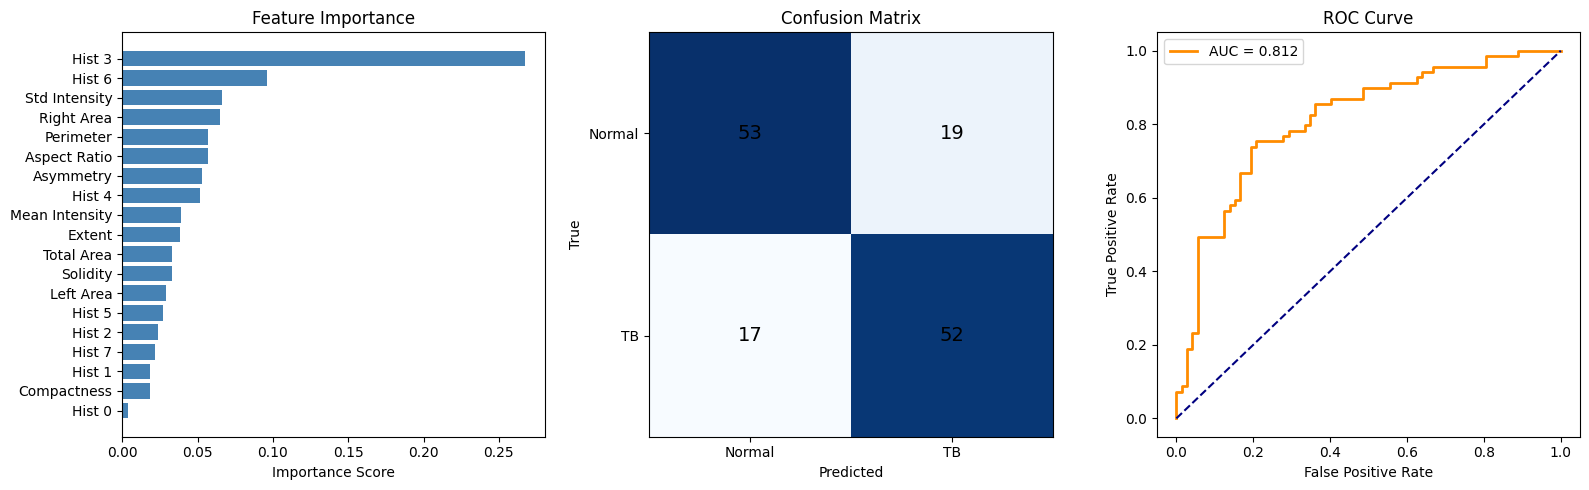

In [68]:
# ── Cell 15: Feature Importance + Confusion Matrix + ROC Curve ──
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Feature Importance
feat_names = [
    'Total Area', 'Left Area', 'Right Area',
    'Perimeter', 'Compactness', 'Solidity', 'Asymmetry',
    'Aspect Ratio', 'Extent',
    'Mean Intensity', 'Std Intensity',
    'Hist 0', 'Hist 1', 'Hist 2', 'Hist 3',
    'Hist 4', 'Hist 5', 'Hist 6', 'Hist 7'
]

importances = clf.feature_importances_
sorted_idx  = np.argsort(importances)

axes[0].barh([feat_names[i] for i in sorted_idx], importances[sorted_idx], color='steelblue')
axes[0].set_title('Feature Importance')
axes[0].set_xlabel('Importance Score')

# 2. Confusion Matrix
cm = confusion_matrix(yf_test, y_pred)
axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(['Normal', 'TB'])
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(['Normal', 'TB'])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i, j], ha='center', va='center', fontsize=14)

# 3. ROC Curve
y_prob = clf.predict_proba(Xf_test)[:, 1]
fpr, tpr, _ = roc_curve(yf_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[2].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve')
axes[2].legend()

plt.tight_layout()
plt.savefig('rf_results.png', dpi=150)
plt.show()